## 1. Data Loading
We load the HR dataset from Databricks table using Spark DataFrame API.
This ensures scalable processing for large datasets.

In [0]:
df = spark.read.table("default.hr_analytics")

Dataset loaded successfully and ready for exploration.

## 2. Data Exploration
We inspect schema, sample data, and structure to understand feature types.

In [0]:
display(df.limit(5))

Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [0]:
import pyspark.sql.functions as F

cols_to_drop = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
df_cleaned = df.drop(*cols_to_drop)

df_cleaned = df_cleaned.withColumn("Attrition", F.when(F.col("Attrition") == "Yes", 1).otherwise(0)) \
                       .withColumn("OverTime", F.when(F.col("OverTime") == "Yes", 1).otherwise(0))

df_cleaned.createOrReplaceTempView("hr_analytics")

display(df_cleaned.limit(5))

Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5
49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7
37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0
33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0
27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2


In [0]:
df_final = df_cleaned.withColumn("EngagementScore", 
    (F.col("JobSatisfaction") + F.col("EnvironmentSatisfaction") + F.col("RelationshipSatisfaction")) / 3) \
    .withColumn("StressIndicator", 
    F.when((F.col("OverTime") == 1) & (F.col("WorkLifeBalance") < 3), 1).otherwise(0)) \
    .withColumn("PromotionRisk", 
    F.when((F.col("YearsSinceLastPromotion") > 3) & (F.col("PerformanceRating") >= 3), 1).otherwise(0))

df_final.createOrReplaceTempView("hr_final")
display(df_final.limit(5))

Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,EngagementScore,StressIndicator,PromotionRisk
41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,1,11,3,1,0,8,0,1,6,4,0,5,2.3333333333333335,1,0
49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,0,23,4,4,1,10,3,3,10,7,1,7,3.0,0,0
37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,1,15,3,2,0,7,3,3,0,0,0,0,3.0,0,0
33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,1,11,3,3,0,8,3,3,8,7,3,0,3.3333333333333335,0,0
27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,0,12,3,4,1,6,3,3,2,2,2,2,2.3333333333333335,0,0


In [0]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
pdf = df_final.toPandas()

cols_to_use = ["Age", "DailyRate", "DistanceFromHome", "Education", "EnvironmentSatisfaction", 
               "HourlyRate", "JobInvolvement", "JobLevel", "JobSatisfaction", "MonthlyIncome", 
               "MonthlyRate", "NumCompaniesWorked", "PercentSalaryHike", "PerformanceRating", 
               "RelationshipSatisfaction", "StockOptionLevel", "TotalWorkingYears", 
               "TrainingTimesLastYear", "WorkLifeBalance", "YearsAtCompany", "YearsInCurrentRole", 
               "YearsSinceLastPromotion", "YearsWithCurrManager", "EngagementScore", 
               "StressIndicator", "PromotionRisk"]

X = pdf[cols_to_use]
y = pdf["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)


print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_preds)}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds)}")

/databricks/python/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:444: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8673469387755102
Random Forest Accuracy: 0.8809523809523809


## 3. Missing Values Analysis
We check for null values to ensure data quality before modeling.

--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       255
           1       0.50      0.03      0.05        39

    accuracy                           0.87       294
   macro avg       0.68      0.51      0.49       294
weighted avg       0.82      0.87      0.81       294

--- Random Forest Report ---
              precision    recall  f1-score   support

           0       0.88      0.99      0.94       255
           1       0.75      0.15      0.26        39

    accuracy                           0.88       294
   macro avg       0.82      0.57      0.60       294
weighted avg       0.87      0.88      0.85       294



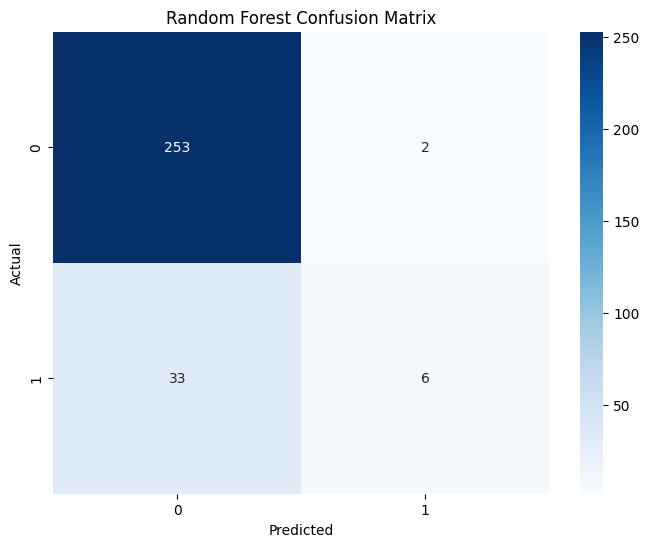

In [0]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Logistic Regression Report ---")
print(classification_report(y_test, lr_preds))

print("--- Random Forest Report ---")
print(classification_report(y_test, rf_preds))

conf_matrix = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

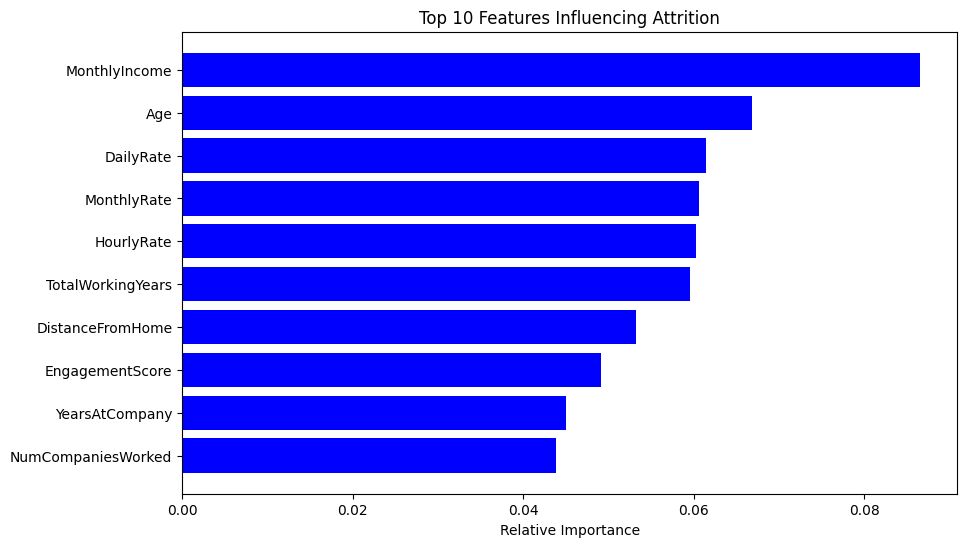

In [0]:
import numpy as np

importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]  # أهم 10 عوامل

plt.figure(figsize=(10, 6))
plt.title('Top 10 Features Influencing Attrition')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [cols_to_use[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

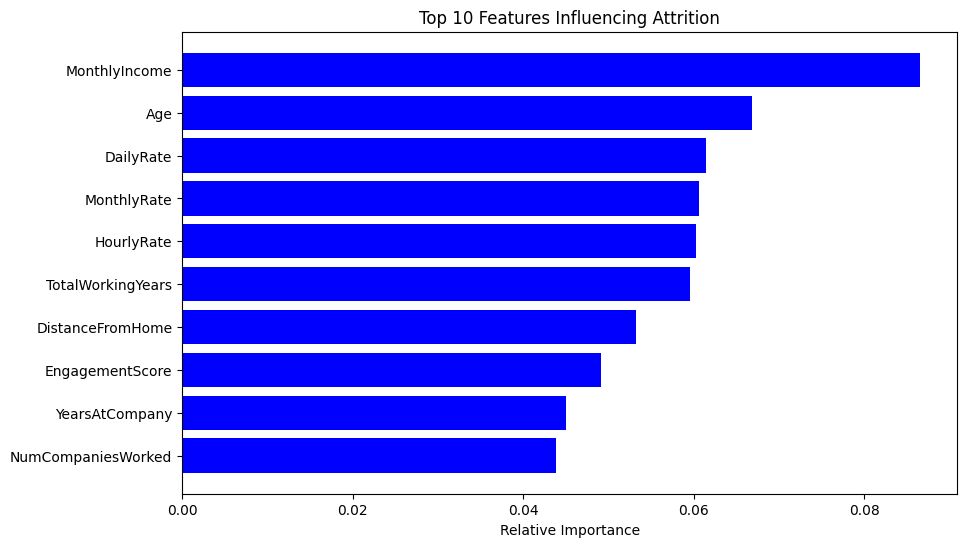

In [0]:
import numpy as np

importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]  # أهم 10 عوامل

plt.figure(figsize=(10, 6))
plt.title('Top 10 Features Influencing Attrition')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [cols_to_use[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7ff3bd98d2d0>
Traceback (most recent call last):
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/databricks/python/lib/python3.10/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'
Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_ca

Logistic Regression Accuracy: 0.8843537414965986
Random Forest Accuracy: 0.8809523809523809
              precision    recall  f1-score   support

           0       0.88      0.99      0.94       255
           1       0.75      0.15      0.26        39

    accuracy                           0.88       294
   macro avg       0.82      0.57      0.60       294
weighted avg       0.87      0.88      0.85       294

Silhouette Score: 0.6234884650050383


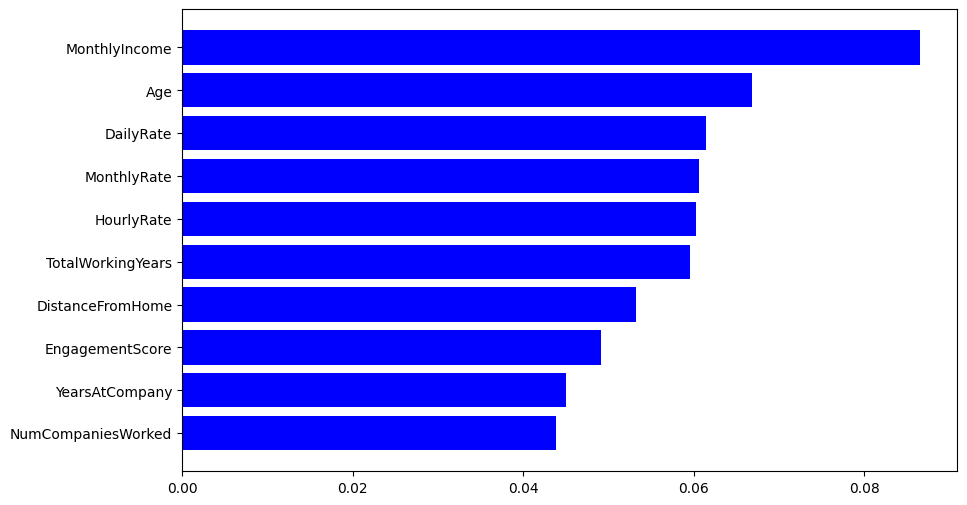

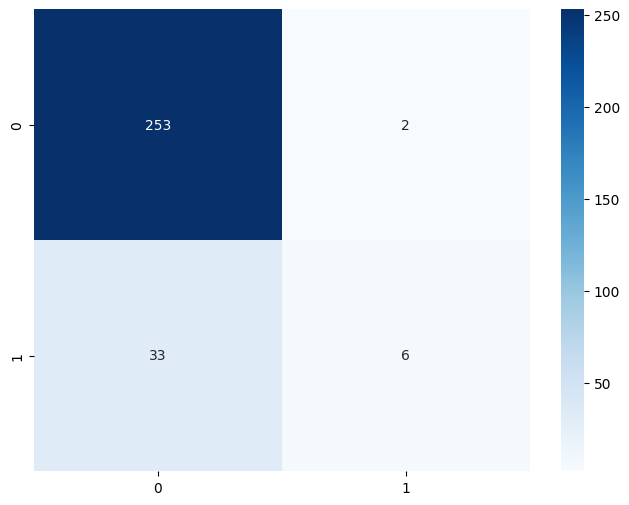

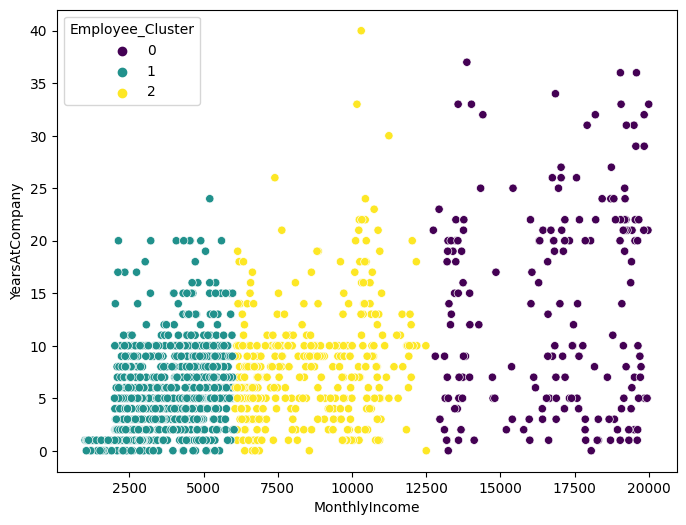

In [0]:
import numpy as np
import pandas as pd
import pyspark.sql.functions as F
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

file_path = "workspace.default.wa_fn_use_c_hr_employee_attrition"
df = spark.read.table(file_path)

cols_to_drop = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
df_cleaned = df.drop(*cols_to_drop)

df_cleaned = df_cleaned.withColumn("Attrition", F.when(F.col("Attrition") == "Yes", 1).otherwise(0)) \
                       .withColumn("OverTime", F.when(F.col("OverTime") == "Yes", 1).otherwise(0))

df_cleaned = df_cleaned.withColumn("EngagementScore", (F.col("JobSatisfaction") + F.col("EnvironmentSatisfaction") + F.col("RelationshipSatisfaction")) / 3) \
    .withColumn("StressIndicator", F.when((F.col("OverTime") == 1) & (F.col("WorkLifeBalance") < 3), 1).otherwise(0)) \
    .withColumn("PromotionRisk", F.when((F.col("YearsSinceLastPromotion") > 3) & (F.col("PerformanceRating") >= 3), 1).otherwise(0))

df_cleaned.createOrReplaceTempView("hr_final")

pdf = df_cleaned.toPandas()

cols_to_use = ["Age", "DailyRate", "DistanceFromHome", "Education", "EnvironmentSatisfaction", 
               "HourlyRate", "JobInvolvement", "JobLevel", "JobSatisfaction", "MonthlyIncome", 
               "MonthlyRate", "NumCompaniesWorked", "PercentSalaryHike", "PerformanceRating", 
               "RelationshipSatisfaction", "StockOptionLevel", "TotalWorkingYears", 
               "TrainingTimesLastYear", "WorkLifeBalance", "YearsAtCompany", "YearsInCurrentRole", 
               "YearsSinceLastPromotion", "YearsWithCurrManager", "EngagementScore", 
               "StressIndicator", "PromotionRisk"]

X = pdf[cols_to_use]
y = pdf["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=5000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_preds)}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds)}")
print(classification_report(y_test, rf_preds))

X_cluster = pdf[["MonthlyIncome", "JobSatisfaction", "YearsAtCompany"]]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pdf["Employee_Cluster"] = kmeans.fit_predict(X_cluster)
print(f"Silhouette Score: {silhouette_score(X_cluster, pdf['Employee_Cluster'])}")

plt.figure(figsize=(10, 6))
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [cols_to_use[i] for i in indices])
plt.show()

plt.figure(figsize=(8, 6))
conf_matrix = confusion_matrix(y_test, rf_preds)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pdf, x="MonthlyIncome", y="YearsAtCompany", hue="Employee_Cluster", palette="viridis")
plt.show()

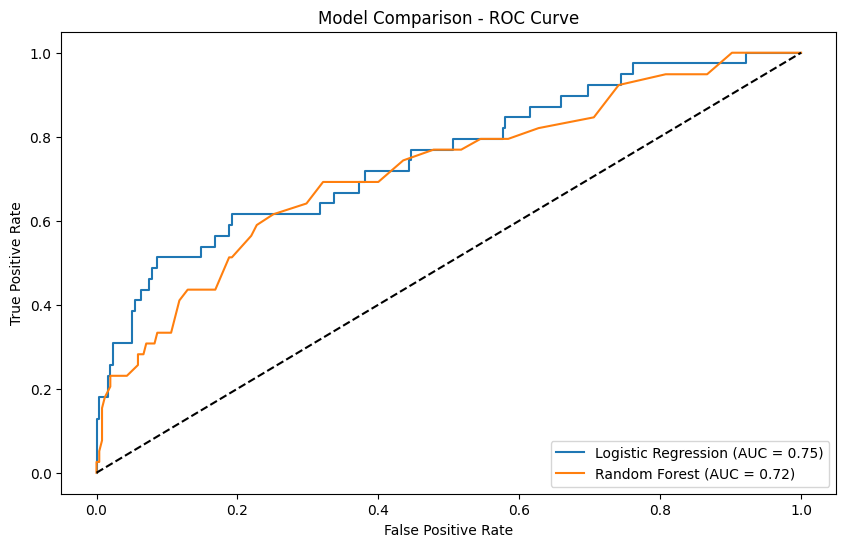

Metric,Logistic Regression,Random Forest
Accuracy,0.8843537414965986,0.8809523809523809
AUC (ROC),0.7519356460532931,0.7201608848667672


--- Explainable AI Insight ---
The model's decision is primarily driven by: MonthlyIncome and Age.


In [0]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve


plt.figure(figsize=(10, 6))


lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')


rf_probs = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model Comparison - ROC Curve')
plt.legend(loc='lower right')
plt.show()

performance_data = {
    'Metric': ['Accuracy', 'AUC (ROC)'],
    'Logistic Regression': [accuracy_score(y_test, lr_preds), roc_auc_lr],
    'Random Forest': [accuracy_score(y_test, rf_preds), roc_auc_rf]
}
performance_df = pd.DataFrame(performance_data)
display(performance_df)


print("--- Explainable AI Insight ---")
top_feature = cols_to_use[indices[-1]]
second_feature = cols_to_use[indices[-2]]
print(f"The model's decision is primarily driven by: {top_feature} and {second_feature}.")